# Análisis de longitud y contexto

### Objetivo

Cuantificar la brecha entre la extensión de los artículos científicos del corpus
`ccdv/arxiv-summarization` y las ventanas de contexto de los modelos preentrenados
del diseño experimental. El análisis mide la longitud de artículos y abstracts en
palabras y en tokens reales de cada modelo, describe su distribución, determina qué
porcentaje de los artículos no cabe en cada ventana y cuánto la excede.

Este notebook continúa el análisis exploratorio de
[`01_eda_dataset.ipynb`](01_eda_dataset.ipynb), que caracterizó la estructura y la
calidad del conjunto de datos. Allí la extensión se midió en palabras y solo en
promedio; aquí se mide con los tokenizadores reales de los modelos, que es la unidad
en la que están definidas las ventanas de contexto.

### Alcance

El análisis se realiza sobre la partición **`test`** (6.440 artículos), que es el
único universo de muestreo del proyecto: no hay *fine-tuning*, de modo que la
distinción train/test no cumple ninguna función experimental, y es la partición
sobre la que la literatura reporta sus resultados (ADR-002). Se usa la configuración
`section`, que preserva los límites de sección del artículo original.

## 1. Preparación

Se cargan el corpus y los tokenizadores de los cuatro modelos del diseño
experimental, y se obtiene la ventana de contexto de cada uno desde su propia
configuración.

In [1]:
# En Colab faltan las dependencias; en el entorno del proyecto (uv) ya están.
import importlib.util

if importlib.util.find_spec('transformers') is None:
    !pip install -q datasets transformers sentencepiece

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

pd.set_option('display.width', 120)


def formato_es(valor, decimales=1):
    """5905.9 -> '5.905,9' — separadores de miles y decimal en español."""
    return f'{valor:,.{decimales}f}'.translate(str.maketrans({',': '.', '.': ','}))


pd.set_option('display.float_format', formato_es)

### 1.1 Estilo de los gráficos

Se fija una paleta única para todo el notebook, de modo que el color signifique
siempre lo mismo: **azul = artículo**, **naranja = abstract**. Las ventanas de
contexto no son series de datos sino umbrales, así que se dibujan como líneas
discontinuas en tinta secundaria y se rotulan directamente.

In [3]:
COLOR = {
    'articulo':  '#2a78d6',   # serie 1 — artículo
    'abstract':  '#eb6834',   # serie 2 — abstract
    'superficie':'#fcfcfb',
    'tinta':     '#0b0b0b',
    'tinta2':    '#52514e',
    'apagado':   '#898781',
    'rejilla':   '#e1e0d9',
    'eje':       '#c3c2b7',
}

plt.rcParams.update({
    'figure.facecolor':  COLOR['superficie'],
    'axes.facecolor':    COLOR['superficie'],
    'savefig.facecolor': COLOR['superficie'],
    'font.family':       'sans-serif',
    'font.size':         10,
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   COLOR['tinta'],
    'axes.labelcolor':   COLOR['tinta2'],
    'axes.edgecolor':    COLOR['eje'],
    'axes.linewidth':    0.8,
    'axes.grid':         True,
    'axes.axisbelow':    True,
    'grid.color':        COLOR['rejilla'],
    'grid.linewidth':    0.8,
    'grid.linestyle':    '-',
    'xtick.color':       COLOR['apagado'],
    'ytick.color':       COLOR['apagado'],
    'xtick.labelcolor':  COLOR['tinta2'],
    'ytick.labelcolor':  COLOR['tinta2'],
    'legend.frameon':    False,
    'figure.dpi':        120,
})


def limpiar(ax, titulo=None, subtitulo=None, x=None, y=None):
    """Quita el marco superior/derecho y rotula los ejes."""
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)
    if titulo:
        ax.set_title(titulo, loc='left', pad=16 if subtitulo else 8)
    if subtitulo:
        ax.text(0, 1.02, subtitulo, transform=ax.transAxes, fontsize=9,
                color=COLOR['tinta2'], va='bottom')
    if x:
        ax.set_xlabel(x)
    if y:
        ax.set_ylabel(y)
    return ax


def marcar_ventana(ax, x, etiqueta, color=None):
    """Dibuja un umbral vertical (una ventana de contexto) y lo rotula.

    La etiqueta va rotada y con un halo del color de la superficie: así
    acompaña a su línea sin taparse con las barras ni con las demás.
    """
    color = color or COLOR['tinta2']
    ax.axvline(x, color=color, linewidth=1.2, linestyle='--', zorder=3)
    ax.text(x, ax.get_ylim()[1] * 0.98, f' {etiqueta}', color=color, fontsize=8.5,
            rotation=90, ha='left', va='top', zorder=4,
            bbox=dict(facecolor=COLOR['superficie'], edgecolor='none', pad=1.5))


miles = FuncFormatter(lambda v, _: f'{v:,.0f}'.replace(',', '.'))

### 1.2 Corpus

In [4]:
from datasets import load_dataset

SPLIT = 'test'   # ADR-002: único universo de muestreo

dataset = load_dataset('ccdv/arxiv-summarization', 'section', split=SPLIT)

articulos = list(dataset['article'])
abstracts = list(dataset['abstract'])

print(f'Partición: {SPLIT}')
print(f'Registros: {formato_es(len(articulos), 0)}')

/Users/carlos/Udea/20262/pi1/repo/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Partición: test
Registros: 6.440


### 1.3 Modelos y ventanas de contexto

El diseño experimental (ADR-003) combina dos modelos de contexto corto —BART y
PEGASUS, que son el objeto de estudio— con dos modelos de contexto largo —LED y
LongT5, que entran como baseline superior de referencia.

La ventana de contexto se lee de la **configuración del modelo**, no del
tokenizador: `tokenizer.model_max_length` devuelve un centinela gigantesco
(≈1e30) cuando el checkpoint no lo declara, que es justamente el caso de
`facebook/bart-large-cnn`. Confiar en ese valor haría que el truncamiento no
truncara nunca. Cada familia declara la ventana en un atributo distinto:
`max_position_embeddings` en BART y PEGASUS, `max_encoder_position_embeddings`
en LED y `n_positions` en LongT5.

In [5]:
from transformers import AutoConfig

MODELOS = {
    'BART':    dict(checkpoint='facebook/bart-large-cnn',        rol='Factorial (contexto corto)'),
    'PEGASUS': dict(checkpoint='google/pegasus-large',           rol='Factorial (contexto corto)'),
    'LongT5':  dict(checkpoint='google/long-t5-tglobal-base',    rol='Baseline de referencia'),
    'LED':     dict(checkpoint='allenai/led-base-16384',         rol='Baseline de referencia'),
}

ATRIBUTOS = ('max_encoder_position_embeddings', 'max_position_embeddings', 'n_positions')


def ventana_de_contexto(checkpoint):
    """Ventana de contexto del codificador, en tokens, según la config del modelo."""
    config = AutoConfig.from_pretrained(checkpoint)
    for atributo in ATRIBUTOS:
        valor = getattr(config, atributo, None)
        if isinstance(valor, int) and 0 < valor < 1_000_000:
            return valor, atributo
    raise RuntimeError(f'{checkpoint} no declara su ventana de contexto.')


for nombre, info in MODELOS.items():
    info['ventana'], info['atributo'] = ventana_de_contexto(info['checkpoint'])

tabla_modelos = pd.DataFrame(MODELOS).T[['checkpoint', 'ventana', 'atributo', 'rol']]
tabla_modelos.columns = ['Checkpoint', 'Ventana (tokens)', 'Atributo de la config', 'Rol']
tabla_modelos

,Checkpoint,Ventana (tokens),Atributo de la config,Rol
BART,facebook/bart-large-cnn,1024,max_position_embeddings,Factorial (contexto corto)
PEGASUS,google/pegasus-large,1024,max_position_embeddings,Factorial (contexto corto)
LongT5,google/long-t5-tglobal-base,4096,n_positions,Baseline de referencia
LED,allenai/led-base-16384,16384,max_encoder_position_embeddings,Baseline de referencia


Las ventanas son **1.024 tokens** para BART y PEGASUS, **4.096** para LongT5 y
**16.384** para LED. Las dos primeras son las que el proyecto estudia; las otras dos
sirven de referencia superior.

Una advertencia sobre LongT5: su atención relativa por segmentos no impone un límite
duro de posiciones, y el valor 4.096 de `n_positions` es el de entrenamiento del
checkpoint, no un tope infranqueable. Se usa ese valor porque es el único que el
modelo declara y porque pasarlo tiene un costo real de memoria, pero conviene leerlo
como *longitud nominal* y no como la barrera categórica que sí son los 1.024 de BART.

## 2. Conteo de palabras y tokens

La longitud se mide en dos unidades distintas y no intercambiables:

- **Palabras**, separando por espacios en blanco. Es la unidad de las estadísticas
  citadas en la literatura (Cohan et al., 2018) y la que permite comparar con el
  planteamiento del problema.
- **Tokens**, con el tokenizador propio de cada modelo. Es la unidad en la que está
  definida la ventana de contexto, y por tanto la única que responde de verdad a la
  pregunta de si un artículo cabe o no.

El conteo de tokens incluye los tokens especiales, porque también ocupan lugar en la
ventana.

### 2.1 Un contador de tokens por modelo

BART y LED comparten el mismo vocabulario BPE, así que un único contador sirve para
ambos. PEGASUS y LongT5 usan SentencePiece.

> **Nota de entorno.** Con `transformers` 5.x, `AutoTokenizer` puede fallar al
> convertir los `spiece.model` de PEGASUS y LongT5 (intenta leerlos como archivos
> *tiktoken*). Por eso el contador cae a SentencePiece directamente cuando la
> conversión falla: se cuentan las piezas del modelo y se suma 1 por el `</s>` final,
> que es exactamente lo que añaden `PegasusTokenizer` y `T5Tokenizer`. El resultado
> es idéntico; cambia solo el camino. En Colab, con `transformers` 4.x, se usa la
> ruta normal de `AutoTokenizer`.

In [6]:
from transformers import AutoTokenizer


def contador_de_tokens(checkpoint):
    """Devuelve una función textos -> array con el número de tokens de cada texto."""
    try:
        tokenizador = AutoTokenizer.from_pretrained(checkpoint)

        def contar(textos):
            codificados = tokenizador(textos, add_special_tokens=True, verbose=False)
            return np.array([len(ids) for ids in codificados['input_ids']])

        return contar

    except Exception as error:
        print(f'   {checkpoint}: AutoTokenizer falló ({type(error).__name__}); '
              'se usa SentencePiece directamente.')
        import sentencepiece as spm
        from huggingface_hub import hf_hub_download

        procesador = spm.SentencePieceProcessor(
            model_file=hf_hub_download(checkpoint, 'spiece.model'))

        def contar(textos):
            # +1 por el </s> que añaden PegasusTokenizer y T5Tokenizer.
            return np.array([len(piezas) + 1 for piezas in procesador.encode(textos)])

        return contar


# LED comparte el tokenizador de BART: se cuenta una sola vez.
TOKENIZADORES = {
    'BART':    'facebook/bart-large-cnn',
    'PEGASUS': 'google/pegasus-large',
    'LongT5':  'google/long-t5-tglobal-base',
}

contadores = {nombre: contador_de_tokens(ck) for nombre, ck in TOKENIZADORES.items()}
print('Contadores listos:', ', '.join(contadores))

[transformers] Could not extract SentencePiece model from /Users/carlos/.cache/huggingface/hub/models--google--pegasus-large/snapshots/dec7796b22f29b7d1c476192313eae8ed57b6b77/spiece.model using sentencepiece library due to 
SentencePieceExtractor requires the protobuf library but it was not found in your environment. Check out the instructions on the
installation page of its repo: https://github.com/protocolbuffers/protobuf/tree/master/python#installation and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.
. Falling back to TikToken extractor.


   google/pegasus-large: AutoTokenizer falló (ValueError); se usa SentencePiece directamente.


Contadores listos: BART, PEGASUS, LongT5


### 2.2 Cálculo de las longitudes

Se construye una tabla con una fila por documento. El identificador se sintetiza por
posición en la partición (`test-00042`), porque el corpus no trae campo `id`
(ADR-002): es lo que permitirá auditar después qué documento produjo cada fila del
experimento.

In [7]:
longitudes = pd.DataFrame({
    'doc_id':   [f'{SPLIT}-{i:05d}' for i in range(len(articulos))],
    'pal_art':  [len(t.split()) for t in articulos],
    'pal_abs':  [len(t.split()) for t in abstracts],
    'car_art':  [len(t) for t in articulos],
    'car_abs':  [len(t) for t in abstracts],
})

for nombre, contar in contadores.items():
    longitudes[f'tok_art_{nombre}'] = contar(articulos)
    longitudes[f'tok_abs_{nombre}'] = contar(abstracts)

# LED usa el mismo vocabulario BPE que BART.
longitudes['tok_art_LED'] = longitudes['tok_art_BART']
longitudes['tok_abs_LED'] = longitudes['tok_abs_BART']

print(f'{formato_es(len(longitudes), 0)} documentos medidos')
longitudes.head()

6.440 documentos medidos


,doc_id,pal_art,pal_abs,car_art,car_abs,tok_art_BART,tok_abs_BART,tok_art_PEGASUS,tok_abs_PEGASUS,tok_art_LongT5,tok_abs_LongT5,tok_art_LED,tok_abs_LED
0,test-00000,5834,213,33254,1259,8050,259,7897,254,8959,289,8050,259
1,test-00001,6526,99,39567,676,12640,121,12971,116,15602,152,12640,121
2,test-00002,2483,90,13476,543,3649,110,3768,107,4416,128,3649,110
3,test-00003,3655,85,21351,502,5200,99,5171,99,5962,124,5200,99
4,test-00004,4465,130,26866,810,6917,222,7055,214,8109,266,6917,222


In [8]:
# Se guarda para no repetir el conteo en análisis posteriores.
from pathlib import Path

salida = Path('data')
salida.mkdir(exist_ok=True)
longitudes.to_csv(salida / f'longitudes_{SPLIT}.csv', index=False)
print('Guardado en', (salida / f'longitudes_{SPLIT}.csv').resolve())

Guardado en /Users/carlos/Udea/20262/pi1/repo/data/longitudes_test.csv


## 3. Estadísticas descriptivas de las longitudes

In [9]:
PERCENTILES = [0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]


def describir(series_por_nombre):
    """Tabla de estadísticas descriptivas: una fila por variable."""
    filas = {}
    for nombre, serie in series_por_nombre.items():
        fila = {'n': serie.size, 'media': serie.mean(), 'desv. est.': serie.std(),
                'mínimo': serie.min()}
        for p in PERCENTILES:
            etiqueta = 'mediana' if p == 0.50 else f'p{int(p * 100)}'
            fila[etiqueta] = serie.quantile(p)
        fila['máximo'] = serie.max()
        filas[nombre] = fila
    return pd.DataFrame(filas).T.round(1)


estad_articulos = describir({
    'Palabras':        longitudes['pal_art'],
    'Caracteres':      longitudes['car_art'],
    'Tokens BART/LED': longitudes['tok_art_BART'],
    'Tokens PEGASUS':  longitudes['tok_art_PEGASUS'],
    'Tokens LongT5':   longitudes['tok_art_LongT5'],
})
estad_articulos

,n,media,desv. est.,mínimo,p5,p25,mediana,p75,p90,p95,p99,máximo
Palabras,"6.440,0","5.905,9","3.892,0","105,0","1.604,9","3.403,8","5.016,5","7.436,2","10.519,4","12.878,6","19.073,3","84.895,0"
Caracteres,"6.440,0","33.062,2","21.874,2","701,0","8.827,8","19.022,5","28.127,5","41.829,8","59.044,2","73.283,0","105.394,7","489.287,0"
Tokens BART/LED,"6.440,0","8.542,1","5.968,3","189,0","2.185,8","4.726,8","7.075,0","10.709,0","15.375,3","19.223,1","29.559,7","110.531,0"
Tokens PEGASUS,"6.440,0","8.591,7","6.019,5","171,0","2.165,9","4.731,5","7.136,0","10.820,2","15.514,5","19.467,8","29.828,3","110.025,0"
Tokens LongT5,"6.440,0","10.185,0","7.206,3","203,0","2.557,0","5.595,8","8.429,5","12.873,2","18.433,2","23.176,9","35.824,4","129.377,0"


### Resultados — artículos

El artículo promedio tiene **5.906 palabras** y **8.542 tokens** de BART. La mediana
(7.075 tokens) está muy por debajo de la media, y el máximo (110.531 tokens) está a
18 desviaciones estándar de ella: la distribución tiene una **cola derecha muy
pesada**, de modo que la media sobreestima al artículo típico y ninguna de las dos
medidas describe bien los casos extremos.

El artículo más corto de la partición tiene 105 palabras (189 tokens) y el más largo
84.895 palabras: **tres órdenes de magnitud** de diferencia dentro del mismo corpus.
Cualquier estrategia de manejo de contexto tendrá que funcionar sobre ese rango
completo, no sobre el promedio.

El conteo por palabras coincide con el registrado en el ADR-002 para esta partición
(5.905), lo que confirma que aquella medición era correcta —pero también que
subestimaba el problema en un 45 %, porque un token BPE es más corto que una palabra.

In [10]:
estad_abstracts = describir({
    'Palabras':        longitudes['pal_abs'],
    'Caracteres':      longitudes['car_abs'],
    'Tokens BART/LED': longitudes['tok_abs_BART'],
    'Tokens PEGASUS':  longitudes['tok_abs_PEGASUS'],
    'Tokens LongT5':   longitudes['tok_abs_LongT5'],
})
estad_abstracts

,n,media,desv. est.,mínimo,p5,p25,mediana,p75,p90,p95,p99,máximo
Palabras,"6.440,0","163,1","57,8","44,0","74,0","118,0","159,0","207,0","246,0","263,0","279,0","290,0"
Caracteres,"6.440,0","966,5","335,4","237,0","444,0","708,0","946,5","1.221,0","1.437,0","1.536,0","1.666,0","1.875,0"
Tokens BART/LED,"6.440,0","209,4","77,1","53,0","94,0","150,0","203,0","264,0","317,0","342,0","392,6","624,0"
Tokens PEGASUS,"6.440,0","203,9","75,9","51,0","90,0","145,0","196,0","257,0","310,0","335,0","382,6","609,0"
Tokens LongT5,"6.440,0","245,7","93,4","58,0","108,0","174,0","237,0","309,0","377,0","409,0","467,0","754,0"


### Resultados — abstracts

Los abstracts son, en comparación, casi uniformes: **163 palabras** de media, mediana
159, y un rango que va de 44 a 290 palabras. La desviación estándar (58 palabras) es
un tercio de la media, frente a dos tercios en los artículos.

Ese techo de 290 palabras no es una casualidad del corpus sino una consecuencia de la
norma editorial: arXiv limita el abstract a 1.920 caracteres. El resumen de
referencia es, por tanto, una variable **acotada por construcción**, mientras que la
entrada no lo está en absoluto. Esa asimetría es el problema del proyecto expresado
en dos filas de una tabla.

En tokens de BART, el abstract más largo ocupa 624 —menos de los 1.024 de la ventana
del decodificador—, de modo que el lado de la generación nunca queda restringido por
la arquitectura. La restricción está solo en la entrada.

### 3.1 Relación entre palabras y tokens, y razón de compresión

Dos razones que conviene tener medidas: cuántos tokens cuesta una palabra en cada
tokenizador, y cuántas veces más largo es el artículo que su resumen de referencia.

In [11]:
razones = pd.DataFrame({
    'Tokens por palabra (artículo)': [
        (longitudes[f'tok_art_{m}'] / longitudes['pal_art']).mean() for m in TOKENIZADORES],
    'Tokens por palabra (abstract)': [
        (longitudes[f'tok_abs_{m}'] / longitudes['pal_abs']).mean() for m in TOKENIZADORES],
}, index=list(TOKENIZADORES)).round(3)

compresion = pd.DataFrame({
    'En palabras':       longitudes['pal_art'] / longitudes['pal_abs'],
    'En tokens (BART)':  longitudes['tok_art_BART'] / longitudes['tok_abs_BART'],
}).agg(['mean', 'median', 'min', 'max']).round(1)
compresion.index = ['media', 'mediana', 'mínimo', 'máximo']

display(razones.map(lambda v: formato_es(v, 2)))
display(compresion.T)

,Tokens por palabra (artículo),Tokens por palabra (abstract)
BART,"1,43","1,29"
PEGASUS,"1,43","1,25"
LongT5,"1,70","1,50"


,media,mediana,mínimo,máximo
En palabras,"39,4","32,7","0,9","489,3"
En tokens (BART),"44,9","36,3","1,2","510,7"


Un token de BART equivale a **0,70 palabras** (1,43 tokens por palabra); en LongT5
la fragmentación es aún mayor, 1,70 tokens por palabra, por el vocabulario más
pequeño (32.000 piezas frente a 50.265). Es la explicación de que LongT5 necesite
contar ~19 % más tokens para el mismo texto: **la longitud no es una propiedad del
documento sino del par documento–tokenizador**.

La razón de compresión mediana es de **36,3 a 1** en tokens de BART. El sistema debe
producir, en el caso típico, un resumen 36 veces más corto que su entrada; en el caso
extremo, 511 veces más corto.

El mínimo de la razón (0,9 en palabras) delata un caso degenerado: **un artículo del
corpus es más corto que su propio abstract**. Es uno solo entre 6.440, y no altera
ninguna conclusión, pero conviene recordarlo al interpretar las métricas por documento
en la Fase 3: en ese caso el resumen de referencia no es un resumen de nada.

## 4. Distribución de las longitudes

Las tablas anteriores describen la distribución con números; los gráficos que siguen
muestran su forma, que es lo que justifica trabajar con percentiles y no solo con
promedios.

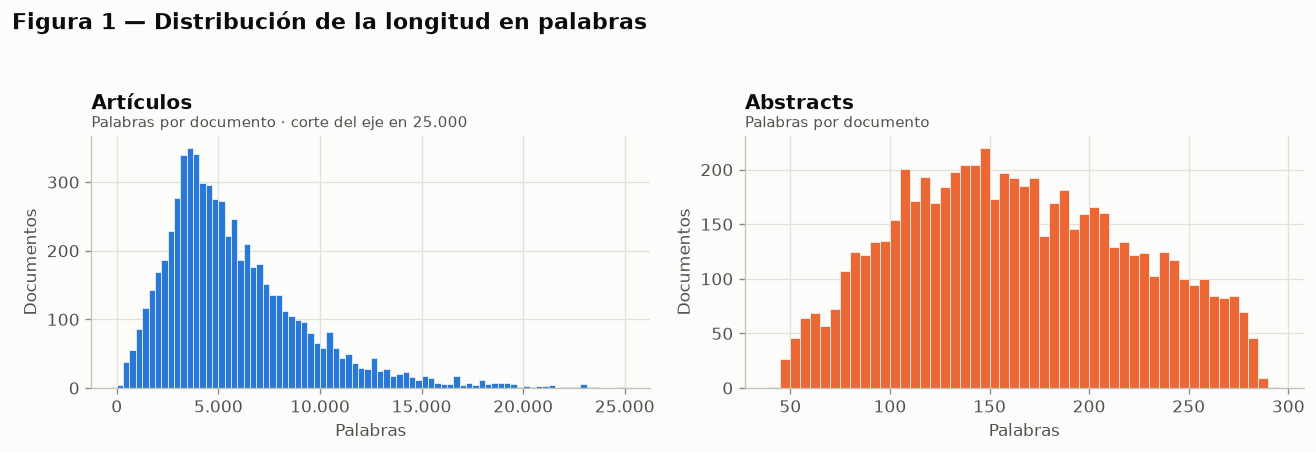

In [12]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.8))

ejes[0].hist(longitudes['pal_art'], bins=80, range=(0, 25000),
             color=COLOR['articulo'], edgecolor=COLOR['superficie'], linewidth=0.4)
limpiar(ejes[0], 'Artículos', 'Palabras por documento · corte del eje en 25.000',
        x='Palabras', y='Documentos')
ejes[0].xaxis.set_major_formatter(miles)
ejes[0].yaxis.set_major_formatter(miles)

ejes[1].hist(longitudes['pal_abs'], bins=np.arange(40, 300, 5),
             color=COLOR['abstract'], edgecolor=COLOR['superficie'], linewidth=0.4)
limpiar(ejes[1], 'Abstracts', 'Palabras por documento', x='Palabras', y='Documentos')
ejes[1].yaxis.set_major_formatter(miles)

fig.suptitle('Figura 1 — Distribución de la longitud en palabras', x=0.005, ha='left',
             fontsize=13, fontweight='bold', color=COLOR['tinta'])
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

Los dos paneles tienen ejes independientes porque comparten unidad pero no escala:
el eje x del panel izquierdo llega a 25.000 palabras (y aun así corta la cola), el del
derecho a 290. La forma es lo distinto: el artículo tiene una distribución sesgada a
la derecha con cola larga, el abstract una distribución casi simétrica con un tope
duro.

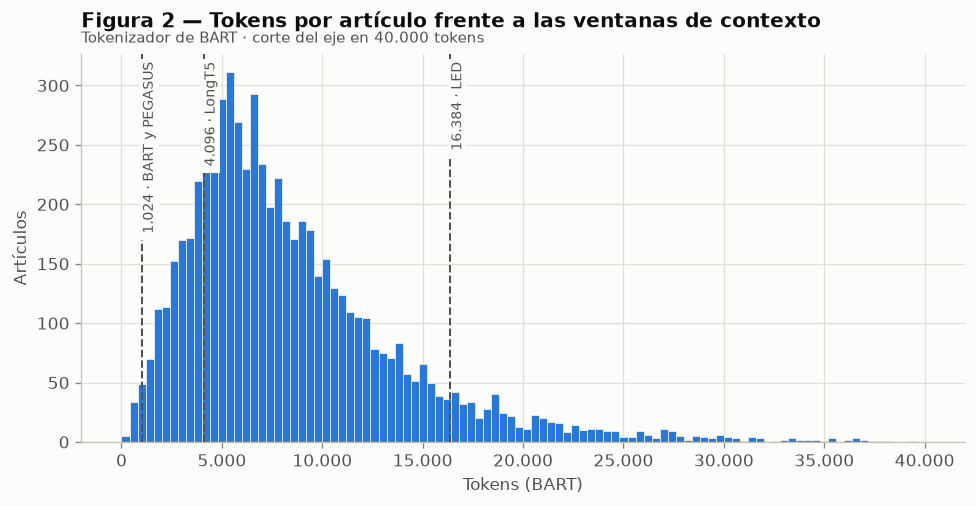

In [13]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))

ax.hist(longitudes['tok_art_BART'], bins=100, range=(0, 40000),
        color=COLOR['articulo'], edgecolor=COLOR['superficie'], linewidth=0.4)
limpiar(ax, 'Figura 2 — Tokens por artículo frente a las ventanas de contexto',
        'Tokenizador de BART · corte del eje en 40.000 tokens',
        x='Tokens (BART)', y='Artículos')
ax.xaxis.set_major_formatter(miles)
ax.yaxis.set_major_formatter(miles)

for ventana, etiqueta in [(1024,  '1.024 · BART y PEGASUS'),
                          (4096,  '4.096 · LongT5'),
                          (16384, '16.384 · LED')]:
    marcar_ventana(ax, ventana, etiqueta)

plt.show()

La línea de 1.024 tokens no separa dos partes de la distribución: cae **antes** de
que la distribución empiece. Esa es la imagen del problema que el proyecto plantea.

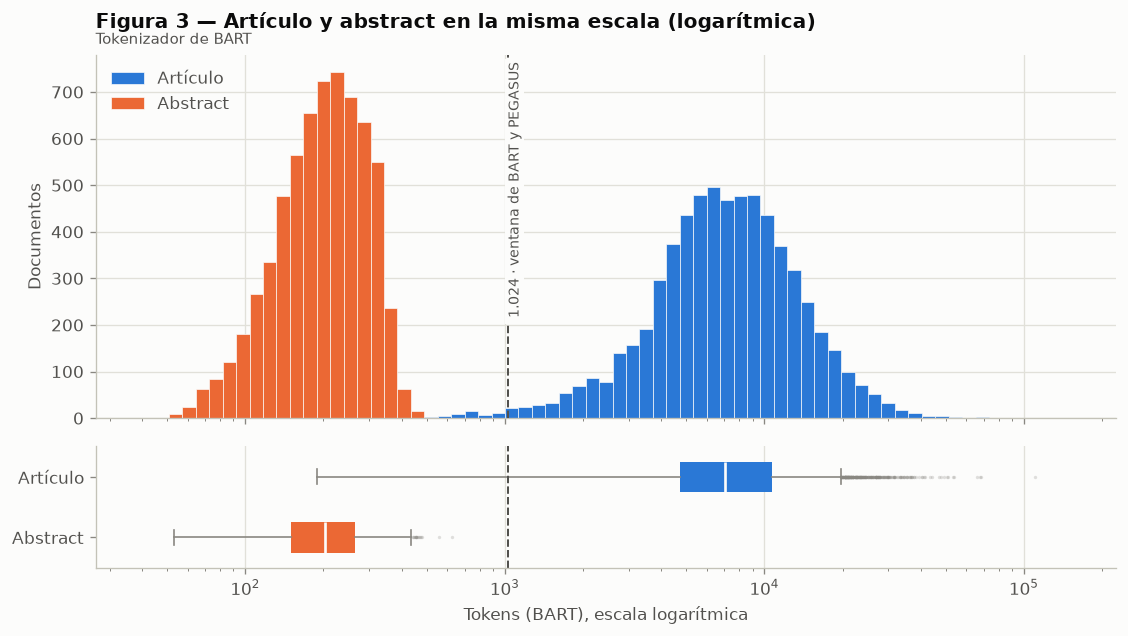

In [14]:
fig, ejes = plt.subplots(2, 1, figsize=(9.5, 5.4), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

bordes = np.logspace(np.log10(40), np.log10(150000), 70)
ejes[0].hist(longitudes['tok_art_BART'], bins=bordes, color=COLOR['articulo'],
             edgecolor=COLOR['superficie'], linewidth=0.4, label='Artículo')
ejes[0].hist(longitudes['tok_abs_BART'], bins=bordes, color=COLOR['abstract'],
             edgecolor=COLOR['superficie'], linewidth=0.4, label='Abstract')
ejes[0].set_xscale('log')
limpiar(ejes[0], 'Figura 3 — Artículo y abstract en la misma escala (logarítmica)',
        'Tokenizador de BART', y='Documentos')
ejes[0].legend(loc='upper left', labelcolor=COLOR['tinta2'])
ejes[0].yaxis.set_major_formatter(miles)
marcar_ventana(ejes[0], 1024, '1.024 · ventana de BART y PEGASUS')

caja = ejes[1].boxplot(
    [longitudes['tok_abs_BART'], longitudes['tok_art_BART']], widths=0.5,
    orientation='horizontal',
    patch_artist=True, tick_labels=['Abstract', 'Artículo'],
    flierprops=dict(marker='o', markersize=2, markerfacecolor=COLOR['apagado'],
                    markeredgecolor='none', alpha=0.25),
    medianprops=dict(color=COLOR['superficie'], linewidth=1.6),
    whiskerprops=dict(color=COLOR['apagado'], linewidth=1),
    capprops=dict(color=COLOR['apagado'], linewidth=1))
for parche, color in zip(caja['boxes'], [COLOR['abstract'], COLOR['articulo']]):
    parche.set_facecolor(color)
    parche.set_edgecolor('none')
limpiar(ejes[1], x='Tokens (BART), escala logarítmica')
ejes[1].grid(axis='y', visible=False)
ejes[1].axvline(1024, color=COLOR['tinta2'], linewidth=1.2, linestyle='--')

fig.tight_layout()
plt.show()

En escala logarítmica se ve que las dos distribuciones apenas se solapan: solo **13
artículos** (0,2 % del corpus) son más cortos que el abstract más largo, que tiene 624
tokens. El diagrama de caja inferior resume la misma información con los
cuartiles: la caja del artículo empieza en 4.727 tokens, es decir, **más del 75 % de
los artículos supera la ventana por un factor de al menos 4,6**.

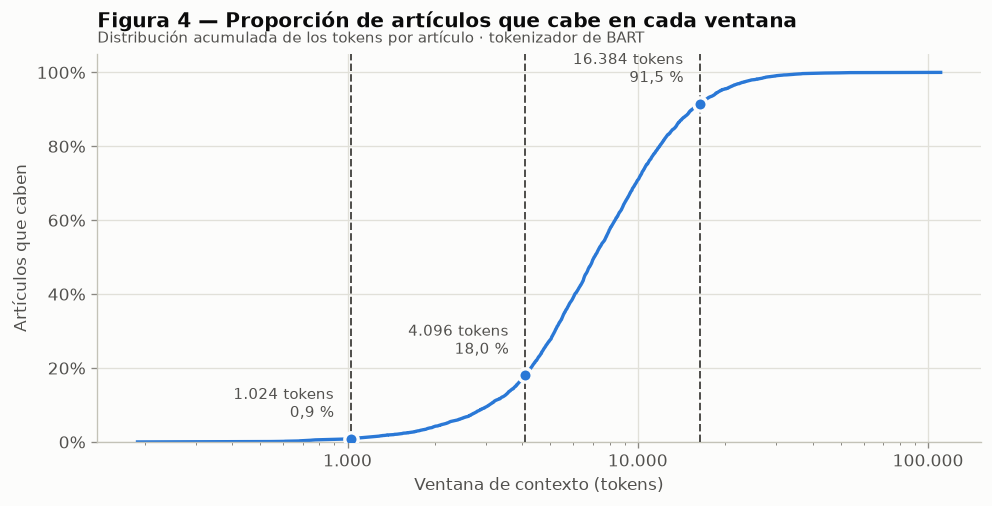

In [15]:
orden = np.sort(longitudes['tok_art_BART'].values)
acumulado = np.arange(1, orden.size + 1) / orden.size

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(orden, acumulado, color=COLOR['articulo'], linewidth=2)
ax.set_xscale('log')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.xaxis.set_major_formatter(miles)
limpiar(ax, 'Figura 4 — Proporción de artículos que cabe en cada ventana',
        'Distribución acumulada de los tokens por artículo · tokenizador de BART',
        x='Ventana de contexto (tokens)', y='Artículos que caben')

for ventana in (1024, 4096, 16384):
    proporcion = (longitudes['tok_art_BART'] <= ventana).mean()
    ax.axvline(ventana, color=COLOR['tinta2'], linewidth=1.2, linestyle='--', zorder=3)
    ax.plot([ventana], [proporcion], marker='o', markersize=8,
            color=COLOR['articulo'], markeredgecolor=COLOR['superficie'],
            markeredgewidth=2, zorder=5)
    # Arriba y a la izquierda del punto: en una curva creciente esa zona
    # siempre está vacía, así que la etiqueta nunca pisa la línea.
    ax.annotate(f'{formato_es(ventana, 0)} tokens\n{formato_es(proporcion * 100)} %',
                xy=(ventana, proporcion), xytext=(-10, 10),
                textcoords='offset points', fontsize=9, color=COLOR['tinta2'],
                ha='right', va='bottom')

ax.set_ylim(0, 1.05)
plt.show()

La curva responde de un vistazo a la pregunta "¿qué ventana haría falta?": para que
el 90 % de los artículos entrara completo se necesitarían unos 15.400 tokens, quince
veces la ventana de los modelos que el proyecto estudia.

(La curva está trazada con el tokenizador de BART, que es también el de LED. Con el
de LongT5 los conteos son ~19 % mayores, lo que desplaza la curva a la derecha; el
porcentaje exacto para LongT5 se calcula en la sección 5 con su propio tokenizador.)

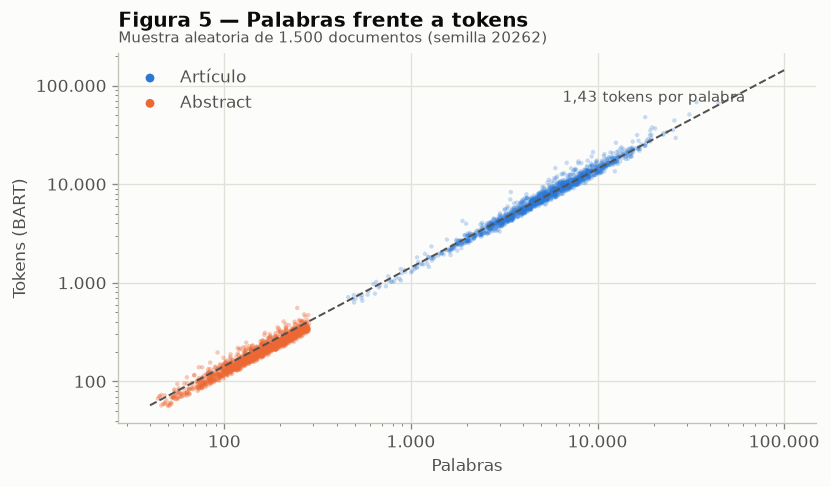

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 4))

muestra = longitudes.sample(1500, random_state=20262)
ax.scatter(muestra['pal_art'], muestra['tok_art_BART'], s=7, alpha=0.25,
           color=COLOR['articulo'], edgecolors='none', label='Artículo')
ax.scatter(muestra['pal_abs'], muestra['tok_abs_BART'], s=7, alpha=0.35,
           color=COLOR['abstract'], edgecolors='none', label='Abstract')
ax.set_xscale('log')
ax.set_yscale('log')
ax.xaxis.set_major_formatter(miles)
ax.yaxis.set_major_formatter(miles)
limpiar(ax, 'Figura 5 — Palabras frente a tokens',
        'Muestra aleatoria de 1.500 documentos (semilla 20262)',
        x='Palabras', y='Tokens (BART)')
leyenda = ax.legend(loc='upper left', labelcolor=COLOR['tinta2'], markerscale=2)
for marca in leyenda.legend_handles:
    marca.set_alpha(1)

limite = np.array([40, 100000])
ax.plot(limite, limite * 1.43, color=COLOR['tinta2'], linewidth=1.2, linestyle='--')
ax.text(20000, 20000 * 1.43 * 2.2, '1,43 tokens por palabra', fontsize=9,
        color=COLOR['tinta2'], ha='center', va='bottom')
plt.show()

La relación entre palabras y tokens es estrecha y prácticamente lineal, lo que
permite una regla práctica: **multiplicar las palabras por 1,43** da una estimación
razonable de los tokens de BART sin ejecutar el tokenizador. Sirve para dimensionar
a ojo, no para decidir el truncamiento —la dispersión alrededor de la recta es de
±10 % y depende de la densidad de fórmulas (`@xmath`) y citas (`@xcite`) del artículo.

## 5. Comparación con las ventanas de contexto

Para cada modelo se compara la longitud de cada artículo, medida con **su propio**
tokenizador, contra **su propia** ventana. Es la comparación que determina si el
problema de contexto largo existe y con qué severidad para cada uno.

In [17]:
def comparar_con_ventana(nombre, info):
    tokenizador = 'BART' if nombre == 'LED' else nombre
    tokens = longitudes[f'tok_art_{tokenizador}'].values
    ventana = info['ventana']
    excede = tokens > ventana
    exceso = np.maximum(0, tokens - ventana)
    descartado = exceso / tokens
    return {
        'Ventana': ventana,
        'Caben completos': int((~excede).sum()),
        '% que cabe': (~excede).mean() * 100,
        '% que excede': excede.mean() * 100,
        'Factor medio (tokens/ventana)': tokens.mean() / ventana,
        'Factor mediano': np.median(tokens) / ventana,
        'Factor máximo': tokens.max() / ventana,
        'Tokens descartados (media)': exceso.mean(),
        '% descartado (media)': descartado.mean() * 100,
        '% descartado (mediana)': np.median(descartado) * 100,
    }


comparacion = pd.DataFrame(
    {nombre: comparar_con_ventana(nombre, info) for nombre, info in MODELOS.items()}).T
comparacion.round(2)

,Ventana,Caben completos,% que cabe,% que excede,Factor medio (tokens/ventana),Factor mediano,Factor máximo,Tokens descartados (media),% descartado (media),% descartado (mediana)
BART,"1.024,0","57,0","0,9","99,1","8,3","6,9","107,9","7.520,7","81,5","85,5"
PEGASUS,"1.024,0","55,0","0,8","99,2","8,4","7,0","107,5","7.570,3","81,6","85,7"
LongT5,"4.096,0","810,0","12,6","87,4","2,5","2,1","31,6","6.258,3","46,3","51,4"
LED,"16.384,0","5.893,0","91,5","8,5","0,5","0,4","6,8","535,0","1,9","0,0"


### Resultados

**Los modelos de contexto corto, que son el objeto de estudio, no pueden procesar el
corpus.** De los 6.440 artículos de la partición, solo **57 caben completos en BART**
y **55 en PEGASUS**. Dicho al revés: el **99,1 %** de los artículos excede la ventana
de BART, y el 99,2 % la de PEGASUS. Los que caben no son artículos cortos normales,
sino casos
atípicos de 105 a 794 palabras —notas breves y contribuciones a congresos—: ni
siquiera el subconjunto que cabe es representativo del corpus.

El artículo medio ocupa **8,3 veces** la ventana de BART; el mediano, 6,9 veces; el
mayor, **108 veces**.

Los modelos de contexto largo cambian la situación pero no la eliminan: LED procesa
completo el **91,5 %** del corpus, y LongT5 solo el **12,6 %** a su longitud nominal
de 4.096 tokens. Que ni siquiera el baseline superior cubra el 100 % del corpus es un
dato relevante para el informe: el 8,5 % de los artículos que LED no puede leer
entero necesitará una estrategia de manejo de contexto **también** en la condición de
referencia.

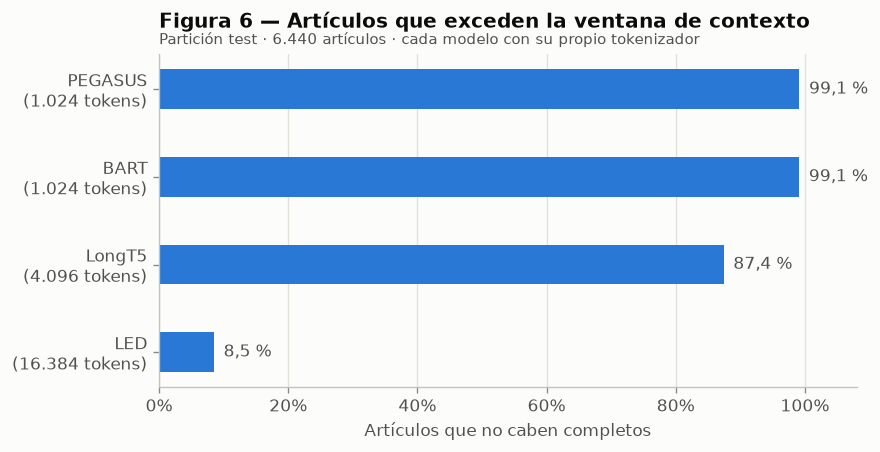

In [18]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))

orden_modelos = comparacion.sort_values('% que excede', ascending=True).index
valores = comparacion.loc[orden_modelos, '% que excede'].astype(float)
etiquetas = [f'{m}\n({formato_es(comparacion.loc[m, "Ventana"], 0)} tokens)'
             for m in orden_modelos]

barras = ax.barh(etiquetas, valores, height=0.45, color=COLOR['articulo'])
for barra, valor in zip(barras, valores):
    ax.text(valor + 1.5, barra.get_y() + barra.get_height() / 2, f'{formato_es(valor)} %',
            va='center', fontsize=10, color=COLOR['tinta2'])

limpiar(ax, 'Figura 6 — Artículos que exceden la ventana de contexto',
        'Partición test · 6.440 artículos · cada modelo con su propio tokenizador',
        x='Artículos que no caben completos')
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.set_xlim(0, 108)
ax.grid(axis='y', visible=False)
plt.show()

### 5.1 El otro extremo: el presupuesto de generación

La ventana de entrada no es la única restricción de longitud del experimento. La
configuración de las celdas del factorial fija `max_new_tokens: 256`, que es el techo
de longitud del resumen generado. Conviene verificar si ese techo es compatible con
la longitud de los resúmenes de referencia contra los que se va a medir el ROUGE.

In [19]:
presupuesto = 256
tokens_abs = longitudes['tok_abs_BART']

print(f'Abstracts que superan max_new_tokens = {presupuesto}: '
      f'{formato_es((tokens_abs > presupuesto).sum(), 0)} '
      f'({formato_es((tokens_abs > presupuesto).mean() * 100)} %)')
print(f'p95 de la longitud del abstract:  {tokens_abs.quantile(0.95):.0f} tokens')
print(f'p99 de la longitud del abstract:  {tokens_abs.quantile(0.99):.0f} tokens')
print(f'máximo:                           {tokens_abs.max():.0f} tokens')

Abstracts que superan max_new_tokens = 256: 1.776 (27,6 %)
p95 de la longitud del abstract:  342 tokens
p99 de la longitud del abstract:  393 tokens
máximo:                           624 tokens


**El 27,6 % de los resúmenes de referencia es más largo que el presupuesto de
generación configurado.** No es un error de medición sino una decisión que conviene
revisar antes de la Fase 3: un sistema que no puede escribir más de 256 tokens pierde
recall de ROUGE en más de un cuarto del corpus por una razón ajena a la estrategia de
contexto, lo que contamina la comparación entre celdas. Subir el techo a **400
tokens** (el p99 es 393) cubre prácticamente todo el corpus con un costo de latencia
marginal. Queda como recomendación a `experiments/configs/`.

## 6. Cuánto exceden los artículos las restricciones

Saber que el 99,1 % de los artículos no cabe dice que el problema existe; cuánto lo
exceden dice cuánta información está en juego y cuánto trabajo tendrá que hacer cada
estrategia para recuperarla.

In [20]:
ventana_corta = MODELOS['BART']['ventana']
tokens_art = longitudes['tok_art_BART'].values

factor = tokens_art / ventana_corta
descartado = np.maximum(0, tokens_art - ventana_corta) / tokens_art
fragmentos = np.ceil(tokens_art / ventana_corta)

exceso = describir({
    'Factor de exceso (× la ventana)': pd.Series(factor),
    '% del artículo descartado':       pd.Series(descartado * 100),
    'Fragmentos de 1.024 tokens':      pd.Series(fragmentos),
})
exceso.round(2)

,n,media,desv. est.,mínimo,p5,p25,mediana,p75,p90,p95,p99,máximo
Factor de exceso (× la ventana),"6.440,0","8,3","5,8","0,2","2,1","4,6","6,9","10,5","15,0","18,8","28,9","107,9"
% del artículo descartado,"6.440,0","81,5","15,2","0,0","53,2","78,3","85,5","90,4","93,3","94,7","96,5","99,1"
Fragmentos de 1.024 tokens,"6.440,0","8,8","5,8","1,0","3,0","5,0","7,0","11,0","16,0","19,0","29,0","108,0"


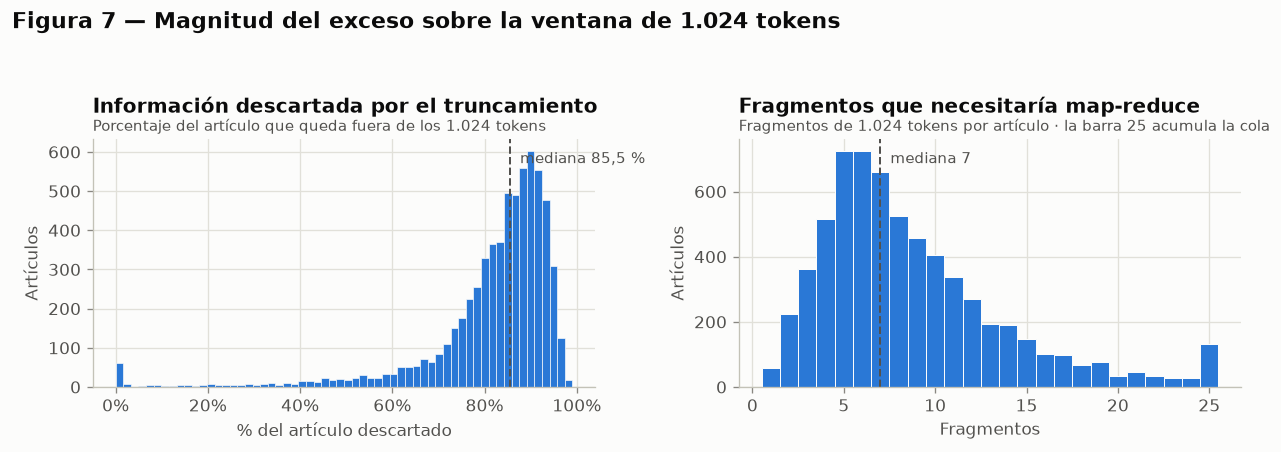

In [21]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.8))

ejes[0].hist(descartado * 100, bins=60, color=COLOR['articulo'],
             edgecolor=COLOR['superficie'], linewidth=0.4)
limpiar(ejes[0], 'Información descartada por el truncamiento',
        'Porcentaje del artículo que queda fuera de los 1.024 tokens',
        x='% del artículo descartado', y='Artículos')
ejes[0].xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ejes[0].yaxis.set_major_formatter(miles)
ejes[0].axvline(np.median(descartado) * 100, color=COLOR['tinta2'],
                linewidth=1.2, linestyle='--')
ejes[0].text(np.median(descartado) * 100, ejes[0].get_ylim()[1] * 0.95,
             f'  mediana {formato_es(np.median(descartado) * 100)} %', fontsize=9,
             color=COLOR['tinta2'], ha='left', va='top')

tope = 25
ejes[1].hist(np.clip(fragmentos, 1, tope), bins=np.arange(0.5, tope + 1.5),
             color=COLOR['articulo'], edgecolor=COLOR['superficie'], linewidth=0.6)
limpiar(ejes[1], 'Fragmentos que necesitaría map-reduce',
        f'Fragmentos de 1.024 tokens por artículo · la barra {tope} acumula la cola',
        x='Fragmentos', y='Artículos')
ejes[1].yaxis.set_major_formatter(miles)
ejes[1].axvline(np.median(fragmentos), color=COLOR['tinta2'],
                linewidth=1.2, linestyle='--')
ejes[1].text(np.median(fragmentos), ejes[1].get_ylim()[1] * 0.95,
             f'  mediana {np.median(fragmentos):.0f}', fontsize=9,
             color=COLOR['tinta2'], ha='left', va='top')

fig.suptitle('Figura 7 — Magnitud del exceso sobre la ventana de 1.024 tokens',
             x=0.005, ha='left', fontsize=13, fontweight='bold', color=COLOR['tinta'])
fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()

### Resultados

El truncamiento a 1.024 tokens descarta en promedio el **81,5 %** del artículo, y el
**85,5 %** en el caso mediano. En tokens absolutos son **7.521 tokens perdidos por
artículo**: más de siete ventanas completas de contenido que el modelo nunca ve.

La distribución del panel izquierdo está apilada contra el extremo derecho —la moda
está por encima del 85 %—, lo que significa que el truncamiento no es una degradación
gradual sino un descarte casi total en casi todo el corpus. Y como el orden de las
secciones de un artículo científico es fijo, lo que se descarta no es una muestra
aleatoria del texto: son sistemáticamente los resultados, la discusión y las
conclusiones. El modelo recibe introducción y trabajo relacionado, y se le pide
resumir hallazgos que están en la parte que no leyó.

El panel derecho traduce el mismo hecho al costo de la alternativa: procesar el
artículo mediano por map-reduce exige **7 pasadas** del modelo, 19 en el p95 y 108 en
el peor caso. Esa es, en unidades de invocaciones al modelo, la factura que map-reduce
paga por no descartar el 85 % del documento, y el compromiso calidad/costo que el
proyecto debe cuantificar (ADR-000).

## 7. Conclusiones

**1. El problema de contexto largo está presente en el corpus y es severo.** El
99,1 % de los artículos de la partición `test` excede la ventana de 1.024 tokens de
BART y PEGASUS. No es una condición de borde que afecte a los artículos más largos:
es la condición normal del corpus, y los 57 documentos que sí caben son atípicos
—textos de menos de 800 palabras— que no representan el caso de uso.

**2. La brecha real es mayor que la registrada hasta ahora.** Medida sobre la
partición completa con el tokenizador de BART, la longitud media es de **8.542
tokens**, es decir **8,3 veces** la ventana. El ADR-002 registraba 7.839 tokens y
7,7× a partir de una muestra de 30 artículos del smoke test de la semana 5; la
medición completa corrige esa cifra al alza. Conviene actualizar el ADR-002 y el
README con los valores de este notebook.

**3. La unidad de medida importa.** El conteo por palabras (5.906) subestima el
problema en un 45 % frente al conteo por tokens BPE, y la longitud depende del
tokenizador: el mismo corpus mide 8.542 tokens en BART, 8.592 en PEGASUS y 10.185 en
LongT5. Toda cifra de longitud que se reporte en el informe debe indicar con qué
tokenizador se obtuvo.

**4. El truncamiento descarta el 81,5 % del artículo en promedio** (85,5 % mediano),
y lo hace sobre las secciones finales, que son las que contienen los resultados. Eso
fija el listón de lo que map-reduce y extractivo-abstractivo tienen que recuperar, y
anticipa que el truncamiento debería ser la cota inferior de calidad del factorial.

**5. El costo de la alternativa está cuantificado.** Map-reduce sobre fragmentos de
1.024 tokens necesita 7 invocaciones del modelo para el artículo mediano y hasta 108
para el más largo. La distribución tiene cola pesada, de modo que la latencia p95
—no la media— es la métrica que debe reportarse, tal como exige el ADR-000.

**6. Ni el baseline de contexto largo cubre todo el corpus.** LED lee completo el
91,5 % de los artículos y LongT5 el 12,6 % a su longitud nominal. El 8,5 % restante
de LED requerirá también una estrategia de manejo de contexto, y debe declararse al
reportar el baseline para no presentarlo como "el modelo que sí lee el artículo
entero".

**7. Hallazgo colateral sobre la configuración del experimento.** El 27,6 % de los
abstracts de referencia supera los 256 tokens de `max_new_tokens` fijados en
`experiments/configs/`. Se recomienda elevar el presupuesto de generación a 400
tokens (p99 = 393) antes de la Fase 3, para que la comparación entre celdas no quede
contaminada por un techo de longitud ajeno a la estrategia de contexto.

### Implicaciones para el diseño experimental

La pregunta de investigación del ADR-000 —qué estrategia de manejo de contexto largo
ofrece el mejor compromiso calidad/costo— queda confirmada como pertinente: con un
99,1 % de artículos fuera de la ventana y un 81,5 % de contenido descartado por
truncamiento, la elección de estrategia no es un detalle de implementación sino la
decisión que determina qué parte del artículo llega al modelo.